# Exercises

There are three exercises in this notebook:

1. Use the cross-validation method to test the linear regression with different $\alpha$ values, at least three.
2. Implement a SGD method that will train the Lasso regression for 10 epochs.
3. Extend the Fisher's classifier to work with two features. Use the class as the $y$.

## 1. Cross-validation linear regression

You need to change the variable ``alpha`` to be a list of alphas. Next do a loop and finally compare the results.

In [2]:
import numpy as np

x = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(-1, 1).reshape(15,1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(-1, 1).reshape(15,1)

x = np.asmatrix(np.c_[np.ones((15,1)),x])

I = np.identity(2)
alphas = [0.01, 0.1, 1.0]

for alpha in alphas:
    w = np.linalg.inv(x.T * x + alpha * I) * x.T * y
    w = np.asarray(w).ravel()
    print(f"alpha={alpha}, w={w}")



alpha=0.01, w=[-167.85534019    1.54416013]
alpha=0.1, w=[-101.72397081    1.16978757]
alpha=1.0, w=[-20.59044706   0.71048616]


## 2. Implement based on the Ridge regression example, the Lasso regression.

Please implement the SGD method and compare the results with the sklearn Lasso regression results.

In [3]:
import numpy as np

def sgd(x, y, alpha=0.1, lr=0.00001, epochs=10):
    n_samples, n_features = x.shape
    w = np.zeros((n_features, 1))

    for epoch in range(epochs):
        for i in range(n_samples):
            xi = x[i, :].reshape(1, -1)
            yi = y[i, 0]

            y_pred = xi @ w
            error = y_pred[0, 0] - yi

            grad = xi.T * error

            l1_grad = alpha * np.sign(w)
            l1_grad[0, 0] = 0

            w = w - lr * (grad + l1_grad)

    return w

In [4]:
x = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(-1, 1).reshape(15,1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(-1, 1).reshape(15,1)

x = np.asmatrix(np.c_[np.ones((15,1)),x])

I = np.identity(2)
alpha = 0.1


w = sgd(x, y, alpha=alpha, lr=0.00001, epochs=10)
w = w.ravel()


In [5]:
from sklearn.linear_model import Lasso

model = Lasso(alpha=0.1)
model.fit(np.array(x[:,1:]), y.ravel())

print(model.intercept_, model.coef_)

-180.85790859980537 [1.61776499]


## 3. Extend the Fisher's classifier

Write numpy code that performs Fisher classification using all the features of Iris data. Choose species nr 1 and 2 as two classes. Plot original data and their projection. Using obtained model classify the flower with the folowing features: [6.45, 2.85, 4.25, 1.25].

Wektor Fishera:
[-0.22684996 -0.35584988  0.44461153  0.79008262]

Średnia projekcji klasa 1: 0.6094091595927021
Średnia projekcji klasa 2: 1.5164055444693956
Próg: 1.0629073520310488
Projekcja nowego kwiatu: 0.3998478953587836
Przewidziana klasa: 1
Klasa: versicolor


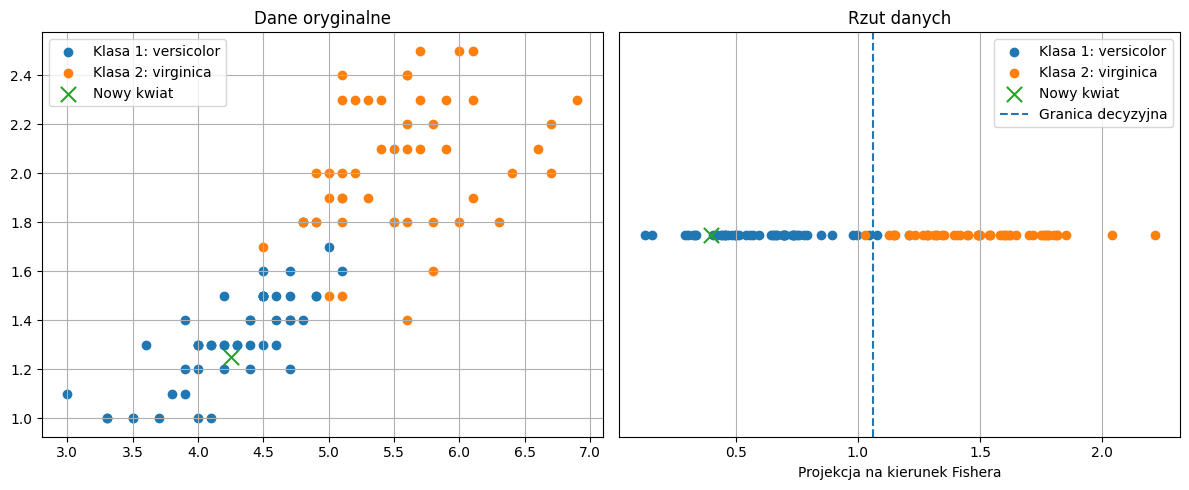

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target
mask = (y == 1) | (y == 2)
X = X[mask]
y = y[mask]

y_binary = np.where(y == 1, 0, 1)
X1 = X[y_binary == 0]
X2 = X[y_binary == 1]
m1 = np.mean(X1, axis=0)
m2 = np.mean(X2, axis=0)

S1 = np.zeros((X.shape[1], X.shape[1]))
for x in X1:
    d = (x - m1).reshape(-1, 1)
    S1 += d @ d.T

S2 = np.zeros((X.shape[1], X.shape[1]))
for x in X2:
    d = (x - m2).reshape(-1, 1)
    S2 += d @ d.T

Sw = S1 + S2

w = np.linalg.inv(Sw) @ (m2 - m1)
w = w / np.linalg.norm(w)

proj = X @ w
proj1 = X1 @ w
proj2 = X2 @ w

mean_proj1 = np.mean(proj1)
mean_proj2 = np.mean(proj2)
threshold = (mean_proj1 + mean_proj2) / 2

new_flower = np.array([6.45, 2.85, 4.25, 1.25])
new_proj = new_flower @ w

if mean_proj1 < mean_proj2:
    predicted_class = 1 if new_proj < threshold else 2
else:
    predicted_class = 1 if new_proj > threshold else 2

print("Wektor Fishera:")
print(w)
print("\nŚrednia projekcji klasa 1:", mean_proj1)
print("Średnia projekcji klasa 2:", mean_proj2)
print("Próg:", threshold)
print("Projekcja nowego kwiatu:", new_proj)
print("Przewidziana klasa:", predicted_class)
print("Klasa:", iris.target_names[predicted_class])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X1[:, 2], X1[:, 3], label='Klasa 1: versicolor')
plt.scatter(X2[:, 2], X2[:, 3], label='Klasa 2: virginica')
plt.scatter(new_flower[2], new_flower[3], marker='x', s=120, label='Nowy kwiat')
plt.title('Dane oryginalne')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(proj1, np.zeros_like(proj1), label='Klasa 1: versicolor')
plt.scatter(proj2, np.zeros_like(proj2), label='Klasa 2: virginica')
plt.scatter(new_proj, 0, marker='x', s=120, label='Nowy kwiat')
plt.axvline(threshold, linestyle='--', label='Granica decyzyjna')
plt.xlabel('Projekcja na kierunek Fishera')
plt.yticks([])
plt.title('Rzut danych')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()